# Income Classification Model

**Project context:** This notebook is my take-home project submission for first-round evaluation.

**Objective:** Build an explainable income propensity model (`> $50K`) using demographic and employment variables from the provided census dataset.

**Business purpose:** Support targeted outreach by ranking records by predicted likelihood of higher income, while preserving population representativeness through sample weights.

**What this notebook demonstrates:**
- data quality and preprocessing choices
- baseline-to-final model selection logic
- weighted evaluation and threshold decision tradeoffs
- interpretable output for business reporting

In [18]:
!/opt/anaconda3/bin/python -m pip install pandas numpy scikit-learn xgboost kmodes

In [19]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore') # Keeps the output clean

## 1. Data Loading
We load the provided schema from `census-bureau.columns` and apply it to `census-bureau.data` to ensure field-level traceability between raw input and modeled features.

In [20]:
import os
print(os.listdir())

['.cursor', 'census-bureau.columns', 'segmentation.ipynb', 'README.md', 'classification.ipynb', 'ML-TakehomeProject.pdf', 'census-bureau.data', '.git']


In [21]:
# Load column names
with open('census-bureau.columns', 'r') as f:
    columns = [line.strip() for line in f.readlines()]

# Load the main dataset
df = pd.read_csv('census-bureau.data', names=columns, header=None)

# Preview the first few rows
df.head()

,age,class of worker,detailed industry recode,detailed occupation recode,education,wage per hour,enroll in edu inst last wk,marital stat,major industry code,major occupation code,...,country of birth father,country of birth mother,country of birth self,citizenship,own business or self employed,fill inc questionnaire for veteran's admin,veterans benefits,weeks worked in year,year,label
0,73,Not in universe,0,0,High school graduate,0,Not in universe,Widowed,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,0,95,- 50000.
1,58,Self-employed-not incorporated,4,34,Some college but no degree,0,Not in universe,Divorced,Construction,Precision production craft & repair,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,2,52,94,- 50000.
2,18,Not in universe,0,0,10th grade,0,High school,Never married,Not in universe or children,Not in universe,...,Vietnam,Vietnam,Vietnam,Foreign born- Not a citizen of U S,0,Not in universe,2,0,95,- 50000.
3,9,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.
4,10,Not in universe,0,0,Children,0,Not in universe,Never married,Not in universe or children,Not in universe,...,United-States,United-States,United-States,Native- Born in the United States,0,Not in universe,0,0,94,- 50000.


## 1.1 Quick EDA (Risk and Decision Context)
Before model training, we validate class balance, data quality, and the impact of population weighting.

Why this matters for risk-oriented decisioning:
- accuracy alone can be misleading under class imbalance
- weighting changes how model performance should be interpreted at population level
- false-positive/false-negative tradeoffs should be explicit before threshold selection

In [22]:
# Target balance (unweighted vs weighted) and basic data quality checks

def weighted_mean(x, w):
    x = np.asarray(x)
    w = np.asarray(w)
    return float(np.sum(x * w) / np.sum(w))

# Map label to binary once for EDA
income_gt_50k = np.where(df['label'].astype(str).str.contains('+', regex=False), 1, 0)

print('Rows:', len(df))
print('Missing values (total):', int(df.isna().sum().sum()))

w_all = df['weight'].astype(float)
print('\nIncome >$50K rate (unweighted):', round(float(income_gt_50k.mean()), 4))
print('Income >$50K rate (weighted):  ', round(weighted_mean(income_gt_50k, w_all), 4))

print('\nRaw label counts:')
print(df['label'].value_counts())

print('\nWeight summary (helps interpret population scaling):')
print(df['weight'].describe())

Rows: 199523
Missing values (total): 874

Income >$50K rate (unweighted): 0.0621
Income >$50K rate (weighted):   0.0641

Raw label counts:
label
- 50000.    187141
50000+.      12382
Name: count, dtype: int64

Weight summary (helps interpret population scaling):
count    199523.000000
mean       1740.380269
std         993.768156
min          37.870000
25%        1061.615000
50%        1618.310000
75%        2188.610000
max       18656.300000
Name: weight, dtype: float64


## 1.2 Interpretable Distribution Checks
These weighted slices provide report-ready evidence for business interpretation (education, labor participation, household context, and demographics).

All summary statements below are population-aware when based on the `weight` column.

In [23]:
# Weighted high-income rate by selected features (report-friendly)
eda_cols = ['education', 'weeks worked in year', 'marital stat', 'sex']

eda_df = df[eda_cols + ['weight']].copy()
eda_df['income_>50k'] = income_gt_50k

for col in eda_cols:
    # Weighted mean of the binary target by group
    tmp = (
        eda_df.groupby(col)
        .apply(lambda g: weighted_mean(g['income_>50k'], g['weight']))
        .sort_values(ascending=False)
        .head(10)
    )
    print(f"\nTop groups by weighted P(income >$50K) for: {col}")
    display((tmp * 100).round(2).to_frame('P(>50K) %'))


Top groups by weighted P(income >$50K) for: education


,P(>50K) %
education,
Prof school degree (MD DDS DVM LLB JD),53.89
Doctorate degree(PhD EdD),52.63
Masters degree(MA MS MEng MEd MSW MBA),31.59
Bachelors degree(BA AB BS),20.35
Associates degree-academic program,9.63
Associates degree-occup /vocational,7.59
Some college but no degree,6.50
High school graduate,3.76
12th grade no diploma,1.48



Top groups by weighted P(income >$50K) for: weeks worked in year


,P(>50K) %
weeks worked in year,
52,15.09
51,11.71
50,10.68
49,9.97
46,9.12
48,8.40
41,8.27
45,6.36
19,5.35



Top groups by weighted P(income >$50K) for: marital stat


,P(>50K) %
marital stat,
Married-civilian spouse present,11.93
Divorced,8.07
Married-spouse absent,5.60
Separated,5.04
Widowed,3.20
Married-A F spouse present,2.50
Never married,1.37



Top groups by weighted P(income >$50K) for: sex


,P(>50K) %
sex,
Male,10.32
Female,2.67


## 2. Data Preprocessing
We separate predictors, target, and sample weights to preserve clean modeling controls.

`weight` is retained in both training and evaluation so model fitting and reported performance reflect population-level representation rather than raw sample frequency.

We use stratified splits to keep class proportions stable across train/validation/test sets.

In [24]:
# 1. Isolate features, weights, and target
X = df.drop(columns=['label', 'weight'])
weights = df['weight']

# 2. Convert label to binary: 1 for income > $50k, 0 for <= $50k.
y = np.where(df['label'].astype(str).str.contains('+', regex=False), 1, 0)

# 3. Identify column types for the pipeline
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 4. FIRST SPLIT: Separate out 15% for the final TEST Set
X_temp, X_test, y_temp, y_test, w_temp, w_test = train_test_split(
    X, y, weights, test_size=0.15, random_state=42, stratify=y
)

# 5. SECOND SPLIT: Split the remaining 85% into TRAIN (70% total) and VAL (15% total)
# 0.15 / 0.85 is roughly 0.1764
X_train, X_val, y_train, y_val, w_train, w_val = train_test_split(
    X_temp, y_temp, w_temp, test_size=0.1764, random_state=42, stratify=y_temp
)

print(f"Training Data: {len(X_train)} rows")
print(f"Validation Data: {len(X_val)} rows")
print(f"Test Data: {len(X_test)} rows")

Training Data: 139677 rows
Validation Data: 29917 rows
Test Data: 29929 rows


## 3. Baseline Model Comparison (Validation Set)
To support defensible model selection, we benchmark linear, tree, and ensemble approaches under a consistent preprocessing pipeline and compare weighted performance on the validation set.

In [25]:
import xgboost as xgb

# Create the preprocessing steps (used for all models)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Define the progression of models
models = {
    "1. Baseline: Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "2. Basic Non-Linear: Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "3. Ensemble (Voting): Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "4. Ensemble (Learning): XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Train and evaluate each model
for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    
    # Train on TRAINING set
    clf.fit(X_train, y_train, classifier__sample_weight=w_train)
    
    # Evaluate on VALIDATION set
    y_pred_val = clf.predict(X_val)
    y_proba_val = clf.predict_proba(X_val)[:, 1]
    
    print(f"\n{'='*60}")
    print(f" {name}")
    print(f"{'='*60}")
    print(classification_report(y_val, y_pred_val, sample_weight=w_val))
    print(f"Validation ROC-AUC: {roc_auc_score(y_val, y_proba_val, sample_weight=w_val):.4f}")


 1. Baseline: Logistic Regression
              precision    recall  f1-score   support

           0       0.96      0.99      0.97 48839316.71000012
           1       0.72      0.38      0.50 3322447.3999999957

    accuracy                           0.95 52161764.11000012
   macro avg       0.84      0.69      0.74 52161764.11000012
weighted avg       0.94      0.95      0.94 52161764.11000012

Validation ROC-AUC: 0.9397

 2. Basic Non-Linear: Decision Tree
              precision    recall  f1-score   support

           0       0.95      0.99      0.97 48839316.71000012
           1       0.69      0.30      0.42 3322447.3999999957

    accuracy                           0.95 52161764.11000012
   macro avg       0.82      0.65      0.70 52161764.11000012
weighted avg       0.94      0.95      0.94 52161764.11000012

Validation ROC-AUC: 0.8946

 3. Ensemble (Voting): Random Forest
              precision    recall  f1-score   support

           0       0.96      0.99      0.97 4

## 4. Hyperparameter Tuning (Validation Set)
XGBoost is selected for tuning because it delivers the strongest weighted ROC-AUC and better positive-class recovery versus baseline alternatives.

Tuning scope is intentionally limited and auditable:
- `max_depth`: interaction complexity / overfit control
- `learning_rate`: update aggressiveness and stability

Final parameter choice is based on **weighted validation ROC-AUC**.

In [26]:
# Define the settings to test for XGBoost
depths = [3, 5, 7]
learning_rates = [0.05, 0.1, 0.2]

best_score = 0
best_params = {}
best_xgb_model = None

print("--- Tuning XGBoost on Validation Set ---\n")

for d in depths:
    for lr in learning_rates:
        # Build pipeline
        clf = Pipeline(steps=[
            ('preprocessor', preprocessor),
            ('classifier', xgb.XGBClassifier(
                max_depth=d, 
                learning_rate=lr, 
                n_estimators=100, # Keeping the number of trees fixed for this test
                use_label_encoder=False, 
                eval_metric='logloss', 
                random_state=42
            ))
        ])
        
        # Train on TRAINING set
        clf.fit(X_train, y_train, classifier__sample_weight=w_train)
        
        # Predict on VALIDATION set
        y_proba_val = clf.predict_proba(X_val)[:, 1]
        score = roc_auc_score(y_val, y_proba_val, sample_weight=w_val)
        
        print(f"Tested max_depth={d}, learning_rate={lr} --> Validation ROC-AUC: {score:.4f}")
        
        # Save best model
        if score > best_score:
            best_score = score
            best_params = {'max_depth': d, 'learning_rate': lr}
            best_xgb_model = clf

print("\n=========================================")
print(f"WINNING XGBOOST SETTINGS: {best_params}")
print(f"BEST VALIDATION SCORE: {best_score:.4f}")
print("=========================================")

--- Tuning XGBoost on Validation Set ---

Tested max_depth=3, learning_rate=0.05 --> Validation ROC-AUC: 0.9421
Tested max_depth=3, learning_rate=0.1 --> Validation ROC-AUC: 0.9454
Tested max_depth=3, learning_rate=0.2 --> Validation ROC-AUC: 0.9474
Tested max_depth=5, learning_rate=0.05 --> Validation ROC-AUC: 0.9458
Tested max_depth=5, learning_rate=0.1 --> Validation ROC-AUC: 0.9482
Tested max_depth=5, learning_rate=0.2 --> Validation ROC-AUC: 0.9475
Tested max_depth=7, learning_rate=0.05 --> Validation ROC-AUC: 0.9481
Tested max_depth=7, learning_rate=0.1 --> Validation ROC-AUC: 0.9488
Tested max_depth=7, learning_rate=0.2 --> Validation ROC-AUC: 0.9470

WINNING XGBOOST SETTINGS: {'max_depth': 7, 'learning_rate': 0.1}
BEST VALIDATION SCORE: 0.9488


In [27]:
# Generate predictions on the unseen TEST set using our best_xgb_model
y_pred_test = best_xgb_model.predict(X_test)
y_proba_test = best_xgb_model.predict_proba(X_test)[:, 1]

print("--- Final Evaluation on Unseen Test Set ---")
print(classification_report(y_test, y_pred_test, sample_weight=w_test))

print("\n--- Final Test ROC-AUC Score ---")
print(f"{roc_auc_score(y_test, y_proba_test, sample_weight=w_test):.4f}")

--- Final Evaluation on Unseen Test Set ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.98 48682785.61000037
           1       0.76      0.46      0.57 3361938.1200000024

    accuracy                           0.96 52044723.73000038
   macro avg       0.86      0.72      0.77 52044723.73000038
weighted avg       0.95      0.96      0.95 52044723.73000038


--- Final Test ROC-AUC Score ---
0.9526


In [28]:
# 1. Combine Train and Validation sets
X_train_full = pd.concat([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])
w_train_full = pd.concat([w_train, w_val])

# 2. Retrain the winning pipeline on the fully combined dataset
print("Retraining best model on combined Train + Validation data...")
best_xgb_model.fit(X_train_full, y_train_full, classifier__sample_weight=w_train_full)

# 3. Generate predictions on the unseen TEST set
y_pred_test = best_xgb_model.predict(X_test)
y_proba_test = best_xgb_model.predict_proba(X_test)[:, 1]

# 4. Print Final Metrics
print("\n--- Final Evaluation on Unseen Test Set ---")
print(classification_report(y_test, y_pred_test, sample_weight=w_test))

print("\n--- Final Test ROC-AUC Score ---")
print(f"{roc_auc_score(y_test, y_proba_test, sample_weight=w_test):.4f}")

Retraining best model on combined Train + Validation data...

--- Final Evaluation on Unseen Test Set ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.98 48682785.61000037
           1       0.74      0.46      0.57 3361938.1200000024

    accuracy                           0.95 52044723.73000038
   macro avg       0.85      0.73      0.77 52044723.73000038
weighted avg       0.95      0.95      0.95 52044723.73000038


--- Final Test ROC-AUC Score ---
0.9533


## 5. Score-to-Decision Translation (Thresholding)
Predicted probability is treated as a ranking score, then converted into operating cutoffs.

For business/risk governance, the decision questions are:
- If outreach budget covers only top `X%`, what positive-class coverage do we retain?
- What is precision at each cutoff, and how much lift do we gain over random targeting?

The table below reports **weighted** precision, recall, and lift on the held-out test set for multiple cutoff levels.

In [29]:
import numpy as np
import pandas as pd

def weighted_rate(y, w):
    y = np.asarray(y)
    w = np.asarray(w)
    return float(np.sum(y * w) / np.sum(w))

def targeting_table(y_true, y_score, w, cutoffs=(0.01, 0.05, 0.10, 0.20, 0.30)):
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    w = np.asarray(w)

    base = weighted_rate(y_true, w)
    total_pos_w = float(np.sum(w * (y_true == 1)))

    # Sort by score descending
    order = np.argsort(-y_score)
    y_sorted = y_true[order]
    s_sorted = y_score[order]
    w_sorted = w[order]

    # Cumulative population weight
    cum_w = np.cumsum(w_sorted)
    total_w = float(np.sum(w_sorted))

    rows = []
    for c in cutoffs:
        cutoff_w = c * total_w
        idx = np.searchsorted(cum_w, cutoff_w, side='left')
        idx = int(min(max(idx, 0), len(y_sorted)-1))

        sel = slice(0, idx + 1)
        sel_w = float(np.sum(w_sorted[sel]))
        sel_pos_w = float(np.sum(w_sorted[sel] * (y_sorted[sel] == 1)))

        precision = sel_pos_w / sel_w if sel_w > 0 else np.nan
        recall = sel_pos_w / total_pos_w if total_pos_w > 0 else np.nan
        lift = precision / base if base > 0 else np.nan

        rows.append({
            'Targeted pop share (weighted)': c,
            'Score threshold (approx)': float(s_sorted[idx]),
            'Precision / Hit-rate (weighted)': precision,
            'Recall / Coverage (weighted)': recall,
            'Lift vs random': lift,
        })

    out = pd.DataFrame(rows)
    # Formatting helpers for display
    out['Targeted pop share (weighted)'] = (out['Targeted pop share (weighted)'] * 100).round(1).astype(str) + '%'
    out['Precision / Hit-rate (weighted)'] = (out['Precision / Hit-rate (weighted)'] * 100).round(2)
    out['Recall / Coverage (weighted)'] = (out['Recall / Coverage (weighted)'] * 100).round(2)
    out['Lift vs random'] = out['Lift vs random'].round(2)
    out['Score threshold (approx)'] = out['Score threshold (approx)'].round(4)
    return base, out

base_rate, tbl = targeting_table(y_test, y_proba_test, w_test)
print('Baseline P(>50K) on Test (weighted):', round(base_rate * 100, 2), '%')
display(tbl)

Baseline P(>50K) on Test (weighted): 6.46 %


,Targeted pop share (weighted),Score threshold (approx),Precision / Hit-rate (weighted),Recall / Coverage (weighted),Lift vs random
0,1.0%,0.8693,91.63,14.23,14.18
1,5.0%,0.4286,67.92,52.58,10.52
2,10.0%,0.1802,48.00,74.31,7.43
3,20.0%,0.0507,29.44,91.15,4.56
4,30.0%,0.0195,20.88,96.97,3.23


## 6. Model Interpretation (Drivers and Controls)
To support explainability, we report global feature importance from the trained XGBoost pipeline.

Model-risk nuance:
- Some high-signal variables (for example, investment-income fields) are close proxies for economic outcome.
- This is acceptable for ranking/prioritization use cases, but should be acknowledged in governance documentation.
- If needed, a restricted-feature sensitivity model can be run to compare performance under stricter business-policy constraints.

Below we present a clearer view at two levels:
1. Top encoded features (exact model inputs)
2. Aggregated base features (business-readable summary)

In [31]:
# Clear feature-importance output for report usage
# 1) encoded-feature level (exact model inputs)
# 2) base-feature level (business-readable roll-up)

feature_names = best_xgb_model.named_steps['preprocessor'].get_feature_names_out()
importances = best_xgb_model.named_steps['classifier'].feature_importances_

imp_encoded = (
    pd.DataFrame({'encoded_feature': feature_names, 'importance': importances})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

# Build a map from encoded features back to base feature names
base_feature_lookup = {}

# Numeric features are represented as: num__<feature>
for col in numerical_cols:
    base_feature_lookup[f'num__{col}'] = col

# Categorical one-hot features are represented as: cat__<feature>_<category_value>
for ef in imp_encoded['encoded_feature']:
    if ef.startswith('num__'):
        continue
    if ef.startswith('cat__'):
        matched = None
        for col in categorical_cols:
            prefix = f'cat__{col}_'
            if ef.startswith(prefix):
                matched = col
                break
        base_feature_lookup[ef] = matched if matched is not None else ef
    else:
        base_feature_lookup[ef] = ef

imp_encoded['base_feature'] = imp_encoded['encoded_feature'].map(lambda x: base_feature_lookup.get(x, x))

imp_base = (
    imp_encoded.groupby('base_feature', as_index=False)['importance']
    .sum()
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

print('Top 15 encoded features (exact model inputs):')
display(imp_encoded[['encoded_feature', 'importance']].head(15).round(6))

print('Top 15 base features (aggregated for business interpretation):')
display(imp_base.head(15).round(6))

print('Interpretation note: encoded features are model-level detail; base features are better for executive communication.')

Top 15 encoded features (exact model inputs):


,encoded_feature,importance
0,cat__tax filer stat_Nonfiler,0.069902
1,num__weeks worked in year,0.065373
2,cat__sex_Female,0.033163
3,num__capital gains,0.021820
4,num__detailed occupation recode,0.021811
5,num__dividends from stocks,0.015803
6,cat__education_High school graduate,0.011107
7,cat__detailed household summary in household_H...,0.010738
8,cat__tax filer stat_Single,0.010336
9,cat__country of birth mother_Scotland,0.009810


Top 15 base features (aggregated for business interpretation):


,base_feature,importance
0,tax filer stat,0.097046
1,education,0.085286
2,state of previous residence,0.076714
3,country of birth father,0.074075
4,country of birth mother,0.070953
5,major industry code,0.068202
6,weeks worked in year,0.065373
7,country of birth self,0.055830
8,detailed household and family stat,0.041666
9,major occupation code,0.039405


Interpretation note: encoded features are model-level detail; base features are better for executive communication.


## 7. Client Recommendation: Operating Threshold and Decision Policy
Using the held-out test set, we recommend selecting a score cutoff through an explicit business rule rather than defaulting to `0.50`.

Decision rule used below:
- prioritize precision/lift to improve campaign efficiency
- maintain meaningful recall so the model still captures a useful share of `>50K` households
- report all metrics in weighted terms to reflect population-level impact

In [ ]:
# Build an explicit operating-threshold recommendation from test-set ranking performance

def threshold_operating_table(y_true, y_score, w, thresholds):
    rows = []
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    w = np.asarray(w)

    base_rate = weighted_rate(y_true, w)

    for t in thresholds:
        pred = (y_score >= t).astype(int)

        tp_w = float(np.sum(w[(pred == 1) & (y_true == 1)]))
        fp_w = float(np.sum(w[(pred == 1) & (y_true == 0)]))
        fn_w = float(np.sum(w[(pred == 0) & (y_true == 1)]))
        tn_w = float(np.sum(w[(pred == 0) & (y_true == 0)]))

        precision = tp_w / (tp_w + fp_w) if (tp_w + fp_w) > 0 else np.nan
        recall = tp_w / (tp_w + fn_w) if (tp_w + fn_w) > 0 else np.nan
        lift = precision / base_rate if base_rate > 0 else np.nan
        targeted_share = (tp_w + fp_w) / (tp_w + fp_w + fn_w + tn_w)

        rows.append({
            'threshold': t,
            'targeted_pop_share': targeted_share,
            'precision': precision,
            'recall': recall,
            'lift_vs_random': lift
        })

    out = pd.DataFrame(rows)
    return base_rate, out

thresholds = np.round(np.arange(0.10, 0.91, 0.05), 2)
base_rate_thr, op_tbl = threshold_operating_table(y_test, y_proba_test, w_test, thresholds)

# Example policy: choose highest precision among candidates with recall >= 0.30
candidate_tbl = op_tbl[op_tbl['recall'] >= 0.30].copy()
if len(candidate_tbl) > 0:
    recommended = candidate_tbl.sort_values('precision', ascending=False).iloc[0]
else:
    recommended = op_tbl.sort_values('lift_vs_random', ascending=False).iloc[0]

print('Baseline weighted positive rate (random targeting):', round(base_rate_thr * 100, 2), '%')
print('\nRecommended operating threshold:')
print(f"  threshold = {recommended['threshold']:.2f}")
print(f"  targeted population share = {recommended['targeted_pop_share'] * 100:.2f}%")
print(f"  precision = {recommended['precision'] * 100:.2f}%")
print(f"  recall = {recommended['recall'] * 100:.2f}%")
print(f"  lift vs random = {recommended['lift_vs_random']:.2f}x")

op_tbl_display = op_tbl.copy()
op_tbl_display['targeted_pop_share'] = (op_tbl_display['targeted_pop_share'] * 100).round(2)
op_tbl_display['precision'] = (op_tbl_display['precision'] * 100).round(2)
op_tbl_display['recall'] = (op_tbl_display['recall'] * 100).round(2)
op_tbl_display['lift_vs_random'] = op_tbl_display['lift_vs_random'].round(2)

display(op_tbl_display.rename(columns={
    'threshold': 'Score threshold',
    'targeted_pop_share': 'Targeted pop share (%)',
    'precision': 'Precision (%)',
    'recall': 'Recall (%)',
    'lift_vs_random': 'Lift vs random (x)'
}))

## 8. Model Governance Notes (Assumptions and Limits)
For project completeness, key model governance points are documented explicitly:

1. **Use case fit:** This model is appropriate for ranking/prioritization, not deterministic approval decisions.
2. **Proxy-variable risk:** Some high-importance variables may be close proxies for economic status; this should be acknowledged in model documentation.
3. **Threshold sensitivity:** Business outcomes are threshold-dependent; periodic recalibration is recommended.
4. **Temporal stability:** Data is historical (1994/1995 census extracts). Population drift over time can degrade current-world performance.
5. **Fairness/ethics check:** Demographic variables can encode structural bias; any production use should include fairness monitoring and policy review.
6. **Monitoring recommendation:** Track score distribution, precision/recall at operating cutoff, and segment-level stability over time.

## 9. Error Analysis: Who is missed by the model? (False Negatives)
A false negative here means an actual `>50K` individual predicted as `<=50K` at the recommended threshold.

This analysis helps identify under-targeted subgroups and supports better campaign design (e.g., alternative products/messages for groups with high miss rates).

In [ ]:
# Weighted false-negative profiling at the recommended threshold
rec_threshold = float(recommended['threshold'])

test_analysis = X_test.copy()
test_analysis['y_true'] = y_test
test_analysis['score'] = y_proba_test
test_analysis['pred'] = (y_proba_test >= rec_threshold).astype(int)
test_analysis['weight'] = w_test.values if hasattr(w_test, 'values') else w_test

test_analysis['is_false_negative'] = ((test_analysis['y_true'] == 1) & (test_analysis['pred'] == 0)).astype(int)

# Overall weighted FN rate among actual positives
actual_pos = test_analysis[test_analysis['y_true'] == 1]
fn_rate_w = weighted_rate(actual_pos['is_false_negative'], actual_pos['weight'])
print(f'Recommended threshold: {rec_threshold:.2f}')
print(f'Weighted False Negative Rate among actual >50K: {fn_rate_w * 100:.2f}%')

# Group-level miss-rate diagnostics (weighted)
profile_cols = ['education', 'marital stat', 'major occupation code', 'sex']

for col in profile_cols:
    grp = actual_pos.groupby(col).apply(
        lambda g: pd.Series({
            'weighted_fn_rate_%': weighted_rate(g['is_false_negative'], g['weight']) * 100,
            'weighted_pop_share_%': (g['weight'].sum() / actual_pos['weight'].sum()) * 100
        })
    ).reset_index()

    # Show the largest weighted groups first so recommendations stay business-relevant
    grp = grp.sort_values(['weighted_pop_share_%', 'weighted_fn_rate_%'], ascending=[False, False]).head(10)
    print(f"\nFalse-negative profile for: {col} (top weighted groups)")
    display(grp.round(2))

## 11. ROC Curve (Test Set)
This plot shows the tradeoff between true positive rate (recall) and false positive rate across all classification thresholds.

Interpretation:
- A curve closer to the top-left indicates stronger discrimination.
- The dashed diagonal is random performance.
- The AUC value summarizes ranking quality in one number.

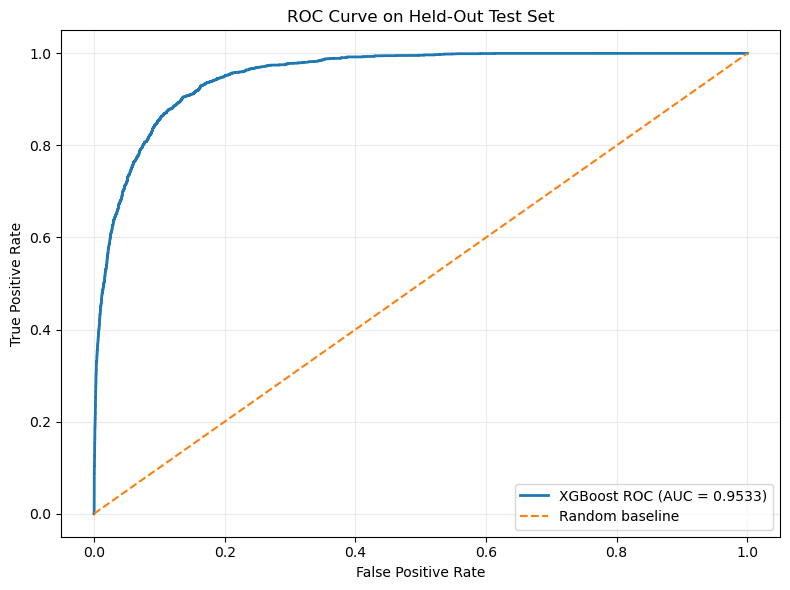

In [32]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Use the test-set probabilities from the trained final model
fpr, tpr, _ = roc_curve(y_test, y_proba_test, sample_weight=w_test)
auc_score = roc_auc_score(y_test, y_proba_test, sample_weight=w_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'XGBoost ROC (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1.5, label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Held-Out Test Set')
plt.legend(loc='lower right')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()